In [ ]:
# Install the additional packages required for imbalanced classification
# and statistical modelling.
!pip install -q imbalanced-learn statsmodels

In [ ]:
# Import warnings to suppress non-critical warning messages.
import warnings

# Suppress warnings to keep the notebook output readable.
warnings.filterwarnings("ignore")

# Import operating-system utilities.
import os

# Import NumPy for numerical operations.
import numpy as np

# Import pandas for data manipulation.
import pandas as pd

# Import matplotlib for visualisation.
import matplotlib.pyplot as plt

# Import seaborn for statistical visualisation.
import seaborn as sns

# Import statistical tests.
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr

# Import multiple-testing correction.
from statsmodels.stats.multitest import multipletests

# Import train-test splitting and cross-validation.
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

# Import preprocessing tools.
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import label_binarize

# Import feature construction tools.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Import the five required classification algorithms.
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Import evaluation metrics.
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

# Import imbalanced-learning tools.
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Set the random seed to make the experiment reproducible.
RANDOM_STATE = 42

# Set a consistent visual style.
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Define the path to the uploaded dataset.
file_path = "email.csv"

# Load the CSV file into a pandas DataFrame.
df_raw = pd.read_csv(file_path)

# Display the first five records.
display(df_raw.head())

# Display the original dataset dimensions.
print(f"Dataset shape: {df_raw.shape}")

,M_ID,SUBJECT,SENT_TS,CONT_TYPE,CONT_SUBTYPE,CONT_PARAM,ENC,USER_AGENT,FROM_P,FROM_U,...,URL1_PROT,URL1_HOST,URL1_FILE,URL2_PROT,URL2_HOST,URL2_FILE,URL3_PROT,URL3_HOST,URL3_FILE,SPAM
0,<30957.1033532534@dimebox.bmc.com>,Bindings problem with current CVS code,1.033530e+12,text,plain,NaN,NaN,NaN,Hal DeVore,haldevore,...,https,listman.redhat.com,mailman/listinfo/exmh-workers,NaN,NaN,NaN,NaN,NaN,NaN,easy-ham
1,<20021203142037.ED16B341D0@lugh.tuatha.org>,[ILUG] MANUEL OKO,1.038929e+12,text,plain,"charset=""iso-8859-1""",7bit,NaN,manueloko1000@netscape.net,manueloko3000,...,http,www.linux.ie,mailman/listinfo/ilug,NaN,NaN,NaN,NaN,NaN,NaN,spam
2,<Pine.LNX.4.33.0208071516330.7395-100000@watch...,Re: Hurtage etc.,1.028760e+12,TEXT,PLAIN,charset=US-ASCII,NaN,NaN,Adam L. Beberg,beberg,...,http,www.mithral.com,~beberg/,http,xent.com,mailman/listinfo/fork,NaN,NaN,NaN,easy-ham-2
3,<m2r8h8t0wv.fsf@maya.dyndns.org>,Shatter Attacks - How to break Windows,1.028910e+12,text,plain,charset=us-ascii,NaN,NaN,Gary Lawrence Murphy,garym,...,http,www.teledyn.com,NaN,http,security.tombom.co.uk,shatter.html,http,xent.com,mailman/listinfo/fork,easy-ham-2
4,<033b23b41b0c$6765b0a5$4ea05aa8@qyxeqo>,cc Prevents diesel fuel gelling 3750r-5,1.021900e+12,text,plain,"charset=""iso-8859-1""",8bit,NaN,NaN,mmoon7y767,...,http,81.9.8.40,cgi-bin/fuelmax/index.cgi?10564,NaN,NaN,NaN,NaN,NaN,NaN,spam-2


Dataset shape: (5961, 53)


In [ ]:
# Display the number of observations.
print(f"Number of records: {df_raw.shape[0]}")

# Display the number of variables.
print(f"Number of columns: {df_raw.shape[1]}")

# Display all column names.
print("\nDataset columns:")

for column in df_raw.columns:
    print(column)

Number of records: 5961
Number of columns: 53

Dataset columns:
M_ID
SUBJECT
SENT_TS
CONT_TYPE
CONT_SUBTYPE
CONT_PARAM
ENC
USER_AGENT
FROM_P
FROM_U
FROM_D
TO_P
TO_U
TO_D
CC_P
CC_U
CC_D
REPLY_P
REPLY_U
REPLY_D
SENDER_P
SENDER_U
SENDER_D
OMTA_NR
OMTA_FROM_H
OMTA_FROM_D
OMTA_BY_H
OMTA_BY_D
OMTA_TS
OMTA_DELAY
OMTA_TT
DMTA_NR
DMTA_FROM_H
DMTA_FROM_D
DMTA_BY_H
DMTA_BY_D
DMTA_TS
DMTA_DELAY
DMTA_TT
ATT_COUNT
ATT_FIRSTNAME
ATT_FIRSTEXT
URL_CNT
URL1_PROT
URL1_HOST
URL1_FILE
URL2_PROT
URL2_HOST
URL2_FILE
URL3_PROT
URL3_HOST
URL3_FILE
SPAM


In [ ]:
# Define the minimum dataset requirements from the assignment brief.
minimum_rows = 2000
minimum_columns = 12

# Check whether the dataset satisfies the row requirement.
rows_valid = df_raw.shape[0] >= minimum_rows

# Check whether the dataset satisfies the column requirement.
columns_valid = df_raw.shape[1] >= minimum_columns

# Display the validation results.
print(f"Rows available: {df_raw.shape[0]}")
print(f"Minimum rows required: {minimum_rows}")
print(f"Rows requirement satisfied: {rows_valid}")

print(f"\nColumns available: {df_raw.shape[1]}")
print(f"Minimum columns required: {minimum_columns}")
print(f"Columns requirement satisfied: {columns_valid}")

Rows available: 5961
Minimum rows required: 2000
Rows requirement satisfied: True

Columns available: 53
Minimum columns required: 12
Columns requirement satisfied: True


In [ ]:
# Display the data type of each variable.
data_type_summary = pd.DataFrame({
    "Column": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
    "Unique Values": [
        df_raw[column].nunique(dropna=True)
        for column in df_raw.columns
    ]
})

# Display the data type summary.
display(data_type_summary)

,Column,Data Type,Unique Values
0,M_ID,object,5960
1,SUBJECT,object,4241
2,SENT_TS,float64,1644
3,CONT_TYPE,object,6
4,CONT_SUBTYPE,object,15
5,CONT_PARAM,object,447
6,ENC,object,9
7,USER_AGENT,object,99
8,FROM_P,object,1545
9,FROM_U,object,2307


In [ ]:
# Calculate the number of missing values in each column.
missing_count = df_raw.isnull().sum()

# Calculate the percentage of missing values.
missing_percentage = (
    missing_count / len(df_raw)
) * 100

# Create a missing-value summary.
missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

# Sort columns by missing-value percentage.
missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

# Display the missing-value summary.
display(missing_summary)

,Missing Values,Missing Percentage
ATT_FIRSTNAME,5941,99.66
ATT_FIRSTEXT,5938,99.61
SENDER_P,5820,97.63
CC_P,5615,94.20
USER_AGENT,5237,87.85
DMTA_FROM_D,4999,83.86
CC_D,4751,79.70
CC_U,4751,79.70
URL3_FILE,4557,76.45
TO_P,4500,75.49


In [ ]:
# Count exact duplicate records.
duplicate_count = df_raw.duplicated().sum()

# Calculate the duplicate percentage.
duplicate_percentage = (
    duplicate_count / len(df_raw)
) * 100

print(f"Exact duplicate records: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Exact duplicate records: 0
Duplicate percentage: 0.00%


In [ ]:
# Display the frequency of every original SPAM category.
spam_category_counts = (
    df_raw["SPAM"]
    .value_counts()
    .sort_index()
)

# Display the counts.
display(spam_category_counts)

# Calculate the percentage distribution.
spam_category_percentage = (
    df_raw["SPAM"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Display the percentage distribution.
display(
    spam_category_percentage.round(2)
)

,count
SPAM,
easy-ham,2500
easy-ham-2,1397
hard-ham,248
spam,485
spam-2,1331


,proportion
SPAM,
easy-ham,41.94
easy-ham-2,23.44
hard-ham,4.16
spam,8.14
spam-2,22.33


In [ ]:
# Define the original categories representing legitimate email.
ham_categories = [
    "easy-ham",
    "easy-ham-2",
    "hard-ham"
]

# Create a binary classification target.
df = df_raw.copy()

df["SPAM_BINARY"] = (
    ~df["SPAM"].isin(ham_categories)
).astype(int)

# Create readable target labels.
df["SPAM_LABEL"] = df["SPAM_BINARY"].map({
    0: "Ham",
    1: "Spam"
})

# Display the new target distribution.
target_distribution = df["SPAM_LABEL"].value_counts()

# Calculate percentages.
target_percentage = (
    df["SPAM_LABEL"]
    .value_counts(normalize=True)
    * 100
)

# Combine counts and percentages.
target_summary = pd.DataFrame({
    "Count": target_distribution,
    "Percentage": target_percentage.round(2)
})

display(target_summary)

,Count,Percentage
SPAM_LABEL,,
Ham,4145,69.54
Spam,1816,30.46


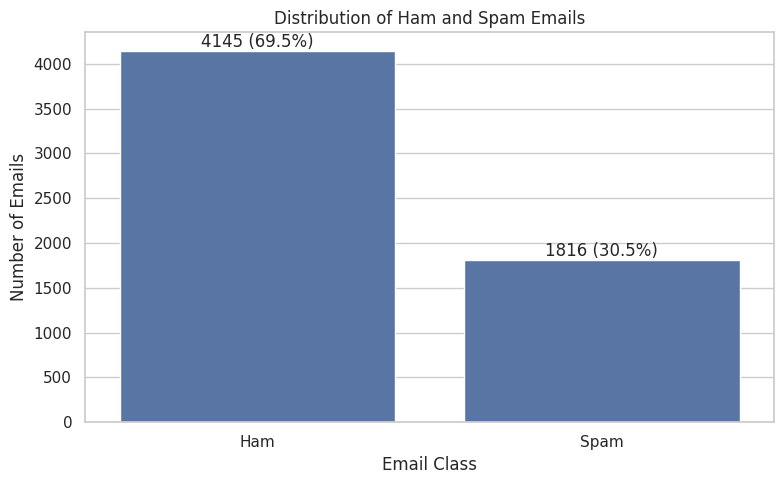

In [ ]:
# Create the target distribution chart.
plt.figure(figsize=(8, 5))

bars = sns.countplot(
    data=df,
    x="SPAM_LABEL",
    order=["Ham", "Spam"]
)

# Add counts above each bar.
for bar in bars.patches:

    count = int(bar.get_height())

    percentage = (
        count / len(df)
    ) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count} ({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Ham and Spam Emails")
plt.xlabel("Email Class")
plt.ylabel("Number of Emails")
plt.tight_layout()
plt.show()

In [ ]:
# Replace missing subjects with an empty string.
df["SUBJECT"] = df["SUBJECT"].fillna("").astype(str)

# Convert subject text to lowercase.
df["SUBJECT_CLEAN"] = (
    df["SUBJECT"]
    .str.lower()
    .str.strip()
)

# Display example subjects.
display(
    df[
        ["SUBJECT", "SUBJECT_CLEAN", "SPAM_LABEL"]
    ].head(10)
)

,SUBJECT,SUBJECT_CLEAN,SPAM_LABEL
0,Bindings problem with current CVS code,bindings problem with current cvs code,Ham
1,[ILUG] MANUEL OKO,[ilug] manuel oko,Spam
2,Re: Hurtage etc.,re: hurtage etc.,Ham
3,Shatter Attacks - How to break Windows,shatter attacks - how to break windows,Ham
4,cc Prevents diesel fuel gelling 3750r-5,cc prevents diesel fuel gelling 3750r-5,Spam
5,[Spambayes] can't write to CVS...,[spambayes] can't write to cvs...,Ham
6,Re: [SAtalk] Spam host?,re: [satalk] spam host?,Ham
7,storage bits,storage bits,Ham
8,Re: JPEGs patented,re: jpegs patented,Ham
9,Netscape 7 Review,netscape 7 review,Ham


In [ ]:
# Calculate the number of characters in each subject.
df["SUBJECT_LENGTH"] = df["SUBJECT_CLEAN"].str.len()

# Calculate the number of words in each subject.
df["SUBJECT_WORD_COUNT"] = (
    df["SUBJECT_CLEAN"]
    .str.split()
    .str.len()
)

# Count exclamation marks.
df["EXCLAMATION_COUNT"] = (
    df["SUBJECT"]
    .str.count("!")
)

# Count question marks.
df["QUESTION_COUNT"] = (
    df["SUBJECT"]
    .str.count(r"\?")
)

# Count dollar symbols.
df["DOLLAR_COUNT"] = (
    df["SUBJECT"]
    .str.count(r"\$")
)

# Count numeric characters.
df["DIGIT_COUNT"] = (
    df["SUBJECT"]
    .str.count(r"\d")
)

# Count uppercase characters in the original subject.
df["UPPERCASE_COUNT"] = (
    df["SUBJECT"]
    .str.count(r"[A-Z]")
)

# Calculate the proportion of uppercase characters.
df["UPPERCASE_RATIO"] = np.where(
    df["SUBJECT_LENGTH"] > 0,
    df["UPPERCASE_COUNT"] / df["SUBJECT_LENGTH"],
    0
)

# Display the engineered features.
display(
    df[
        [
            "SUBJECT",
            "SUBJECT_LENGTH",
            "SUBJECT_WORD_COUNT",
            "EXCLAMATION_COUNT",
            "QUESTION_COUNT",
            "DOLLAR_COUNT",
            "DIGIT_COUNT",
            "UPPERCASE_COUNT",
            "UPPERCASE_RATIO"
        ]
    ].head()
)

,SUBJECT,SUBJECT_LENGTH,SUBJECT_WORD_COUNT,EXCLAMATION_COUNT,QUESTION_COUNT,DOLLAR_COUNT,DIGIT_COUNT,UPPERCASE_COUNT,UPPERCASE_RATIO
0,Bindings problem with current CVS code,38,6,0,0,0,0,4,0.105263
1,[ILUG] MANUEL OKO,17,3,0,0,0,0,13,0.764706
2,Re: Hurtage etc.,16,3,0,0,0,0,2,0.125000
3,Shatter Attacks - How to break Windows,38,7,0,0,0,0,4,0.105263
4,cc Prevents diesel fuel gelling 3750r-5,39,6,0,0,0,5,1,0.025641


In [ ]:
# Select the engineered numerical text features.
text_features = [
    "SUBJECT_LENGTH",
    "SUBJECT_WORD_COUNT",
    "EXCLAMATION_COUNT",
    "QUESTION_COUNT",
    "DOLLAR_COUNT",
    "DIGIT_COUNT",
    "UPPERCASE_COUNT",
    "UPPERCASE_RATIO"
]

# Calculate class-wise means.
text_class_summary = (
    df.groupby("SPAM_LABEL")[text_features]
    .mean()
    .T
)

# Display the summary.
display(
    text_class_summary.round(3)
)

SPAM_LABEL,Ham,Spam
SUBJECT_LENGTH,37.162,39.786
SUBJECT_WORD_COUNT,5.921,5.899
EXCLAMATION_COUNT,0.035,0.404
QUESTION_COUNT,0.131,0.077
DOLLAR_COUNT,0.003,0.084
DIGIT_COUNT,0.696,1.769
UPPERCASE_COUNT,4.473,6.743
UPPERCASE_RATIO,0.128,0.180


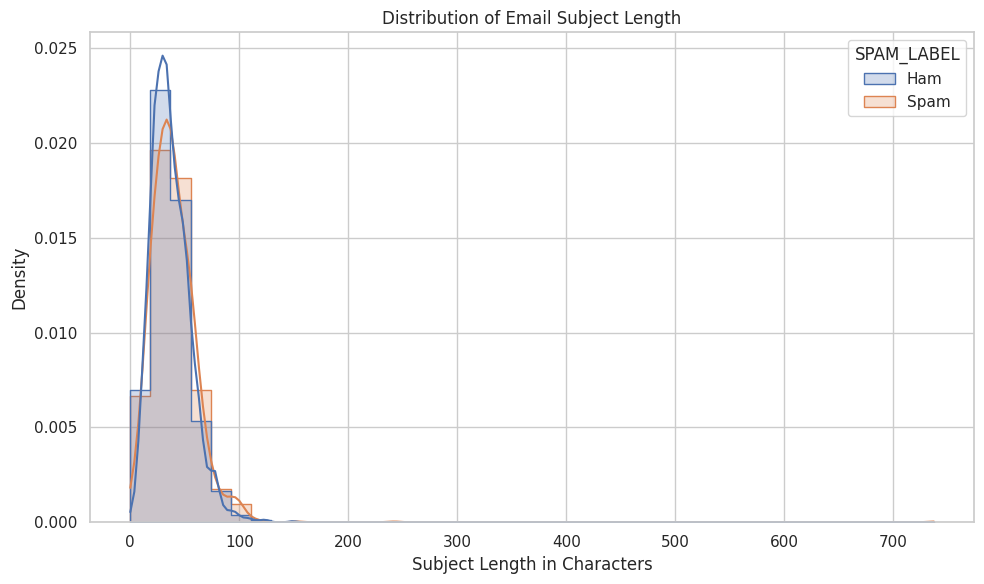

In [ ]:
# Create a distribution plot for subject length.
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="SUBJECT_LENGTH",
    hue="SPAM_LABEL",
    bins=40,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribution of Email Subject Length")
plt.xlabel("Subject Length in Characters")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [ ]:
# Create a function for extracting frequent words from email subjects.
def get_top_words(text_series, number_of_words=20):

    # Combine all subjects into one text string.
    combined_text = " ".join(
        text_series.astype(str)
    )

    # Tokenise the text using whitespace.
    words = combined_text.split()

    # Count each word.
    word_counts = pd.Series(words).value_counts()

    # Return the most frequent words.
    return word_counts.head(number_of_words)

# Extract top words from Ham subjects.
ham_words = get_top_words(
    df.loc[
        df["SPAM_BINARY"] == 0,
        "SUBJECT_CLEAN"
    ]
)

# Extract top words from Spam subjects.
spam_words = get_top_words(
    df.loc[
        df["SPAM_BINARY"] == 1,
        "SUBJECT_CLEAN"
    ]
)

print("Most frequent Ham subject tokens:")
display(ham_words)

print("Most frequent Spam subject tokens:")
display(spam_words)

Most frequent Ham subject tokens:


,count
re:,2416
the,554
[ilug],554
for,367
to,337
a,271
of,252
[razor-users],219
on,212
and,193


Most frequent Spam subject tokens:


,count
your,286
for,164
the,163
you,153
a,150
to,143
free,130
and,93
-,88
of,80


In [ ]:
# Create a modelling copy of the dataset.
model_df = df.copy()

# Calculate whether a CC field is present.
model_df["HAS_CC"] = (
    model_df["CC_D"].notna()
).astype(int)

# Calculate whether a Reply-To address is present.
model_df["HAS_REPLY_TO"] = (
    model_df["REPLY_D"].notna()
).astype(int)

# Calculate whether a Sender address is present.
model_df["HAS_SENDER"] = (
    model_df["SENDER_D"].notna()
).astype(int)

# Calculate whether an attachment exists.
model_df["HAS_ATTACHMENT"] = (
    model_df["ATT_COUNT"] > 0
).astype(int)

# Calculate whether any URL exists.
model_df["HAS_URL"] = (
    model_df["URL_CNT"].fillna(0) > 0
).astype(int)

# Count the number of populated URL host fields.
model_df["URL_HOST_COUNT"] = (
    model_df[
        ["URL1_HOST", "URL2_HOST", "URL3_HOST"]
    ]
    .notna()
    .sum(axis=1)
)

# Count the number of populated URL protocol fields.
model_df["URL_PROTOCOL_COUNT"] = (
    model_df[
        ["URL1_PROT", "URL2_PROT", "URL3_PROT"]
    ]
    .notna()
    .sum(axis=1)
)

# Create a feature indicating whether sender and recipient domains match.
model_df["SENDER_RECIPIENT_DOMAIN_MATCH"] = (
    model_df["FROM_D"].fillna("").str.lower()
    ==
    model_df["TO_D"].fillna("").str.lower()
).astype(int)

# Extract the year from the sent timestamp where possible.
sent_datetime = pd.to_datetime(
    model_df["SENT_TS"],
    unit="ms",
    errors="coerce"
)

# Extract the hour of the email.
model_df["SENT_HOUR"] = (
    sent_datetime.dt.hour.fillna(0)
)

# Extract the day of the week.
model_df["SENT_DAY_OF_WEEK"] = (
    sent_datetime.dt.dayofweek.fillna(0)
)

# Display the new metadata features.
metadata_features = [
    "HAS_CC",
    "HAS_REPLY_TO",
    "HAS_SENDER",
    "HAS_ATTACHMENT",
    "HAS_URL",
    "URL_HOST_COUNT",
    "URL_PROTOCOL_COUNT",
    "SENDER_RECIPIENT_DOMAIN_MATCH",
    "SENT_HOUR",
    "SENT_DAY_OF_WEEK"
]

display(
    model_df[
        metadata_features
    ].head()
)

,HAS_CC,HAS_REPLY_TO,HAS_SENDER,HAS_ATTACHMENT,HAS_URL,URL_HOST_COUNT,URL_PROTOCOL_COUNT,SENDER_RECIPIENT_DOMAIN_MATCH,SENT_HOUR,SENT_DAY_OF_WEEK
0,0,1,1,0,1,1,1,0,3,2
1,0,1,1,0,1,1,1,0,15,1
2,1,1,1,0,1,2,2,0,22,2
3,0,1,1,0,1,3,3,0,16,4
4,0,1,0,0,1,1,1,0,13,0


In [ ]:
# Define the numerical metadata features.
numeric_features = [
    "SUBJECT_LENGTH",
    "SUBJECT_WORD_COUNT",
    "EXCLAMATION_COUNT",
    "QUESTION_COUNT",
    "DOLLAR_COUNT",
    "DIGIT_COUNT",
    "UPPERCASE_COUNT",
    "UPPERCASE_RATIO",
    "OMTA_NR",
    "DMTA_NR",
    "ATT_COUNT",
    "URL_CNT",
    "URL_HOST_COUNT",
    "URL_PROTOCOL_COUNT",
    "HAS_CC",
    "HAS_REPLY_TO",
    "HAS_SENDER",
    "HAS_ATTACHMENT",
    "HAS_URL",
    "SENDER_RECIPIENT_DOMAIN_MATCH",
    "SENT_HOUR",
    "SENT_DAY_OF_WEEK"
]

# Generate descriptive statistics.
numeric_summary = (
    model_df[numeric_features]
    .describe()
    .T
)

# Add median values.
numeric_summary["median"] = (
    model_df[numeric_features]
    .median()
)

# Display the statistics.
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,median
SUBJECT_LENGTH,5961.0,37.961584,20.621925,0.0,24.000000,35.000000,49.000000,737.0,35.000000
SUBJECT_WORD_COUNT,5961.0,5.914108,3.182904,0.0,4.000000,6.000000,7.000000,105.0,6.000000
EXCLAMATION_COUNT,5961.0,0.147626,0.751518,0.0,0.000000,0.000000,0.000000,42.0,0.000000
QUESTION_COUNT,5961.0,0.114914,0.354332,0.0,0.000000,0.000000,0.000000,5.0,0.000000
DOLLAR_COUNT,5961.0,0.027680,0.276736,0.0,0.000000,0.000000,0.000000,12.0,0.000000
DIGIT_COUNT,5961.0,1.023150,2.535149,0.0,0.000000,0.000000,0.000000,25.0,0.000000
UPPERCASE_COUNT,5961.0,5.164402,5.511442,0.0,2.000000,4.000000,6.000000,81.0,4.000000
UPPERCASE_RATIO,5961.0,0.144286,0.141079,0.0,0.060606,0.113208,0.179487,1.0,0.113208
OMTA_NR,5961.0,0.977353,0.148789,0.0,1.000000,1.000000,1.000000,1.0,1.000000
DMTA_NR,5961.0,5.408656,2.420983,0.0,3.000000,6.000000,7.000000,15.0,6.000000


In [ ]:
# Calculate Spearman correlations because several features are
# counts or derived variables that may not follow normal distributions.
spearman_matrix = (
    model_df[numeric_features]
    .corr(method="spearman")
)

# Display the correlation matrix.
display(
    spearman_matrix.round(3)
)

,SUBJECT_LENGTH,SUBJECT_WORD_COUNT,EXCLAMATION_COUNT,QUESTION_COUNT,DOLLAR_COUNT,DIGIT_COUNT,UPPERCASE_COUNT,UPPERCASE_RATIO,OMTA_NR,DMTA_NR,...,URL_HOST_COUNT,URL_PROTOCOL_COUNT,HAS_CC,HAS_REPLY_TO,HAS_SENDER,HAS_ATTACHMENT,HAS_URL,SENDER_RECIPIENT_DOMAIN_MATCH,SENT_HOUR,SENT_DAY_OF_WEEK
SUBJECT_LENGTH,1.000,0.860,0.107,0.045,0.097,0.272,0.424,-0.117,0.051,-0.022,...,0.126,0.127,0.070,0.015,-0.067,-0.044,0.060,-0.005,-0.005,-0.011
SUBJECT_WORD_COUNT,0.860,1.000,0.119,0.072,0.091,0.231,0.436,-0.026,0.121,0.010,...,0.104,0.104,0.075,0.016,-0.010,-0.045,0.084,0.008,0.001,-0.022
EXCLAMATION_COUNT,0.107,0.119,1.000,-0.072,0.113,0.081,0.141,0.096,0.050,-0.124,...,0.066,0.067,0.006,0.004,-0.194,-0.006,0.005,-0.018,0.005,0.056
QUESTION_COUNT,0.045,0.072,-0.072,1.000,-0.032,-0.019,-0.022,-0.061,-0.113,0.038,...,0.002,0.002,0.036,0.004,0.082,0.001,-0.005,-0.093,0.025,0.002
DOLLAR_COUNT,0.097,0.091,0.113,-0.032,1.000,0.275,0.034,-0.013,0.023,-0.050,...,0.026,0.028,-0.017,0.002,-0.102,-0.010,-0.018,-0.024,0.004,0.019
DIGIT_COUNT,0.272,0.231,0.081,-0.019,0.275,1.000,0.124,-0.026,0.083,-0.053,...,0.087,0.087,0.007,0.007,-0.108,-0.013,0.024,-0.084,-0.033,0.030
UPPERCASE_COUNT,0.424,0.436,0.141,-0.022,0.034,0.124,1.000,0.806,0.130,0.086,...,0.091,0.089,0.089,0.004,0.116,-0.033,0.067,-0.151,0.072,-0.005
UPPERCASE_RATIO,-0.117,-0.026,0.096,-0.061,-0.013,-0.026,0.806,1.000,0.119,0.115,...,0.025,0.022,0.070,-0.006,0.165,-0.010,0.047,-0.149,0.084,-0.005
OMTA_NR,0.051,0.121,0.050,-0.113,0.023,0.083,0.130,0.119,1.000,0.261,...,0.195,0.194,0.077,-0.002,0.172,0.010,0.258,0.065,0.001,-0.100
DMTA_NR,-0.022,0.010,-0.124,0.038,-0.050,-0.053,0.086,0.115,0.261,1.000,...,-0.015,-0.018,0.213,0.021,0.692,-0.008,0.096,-0.378,0.134,-0.083


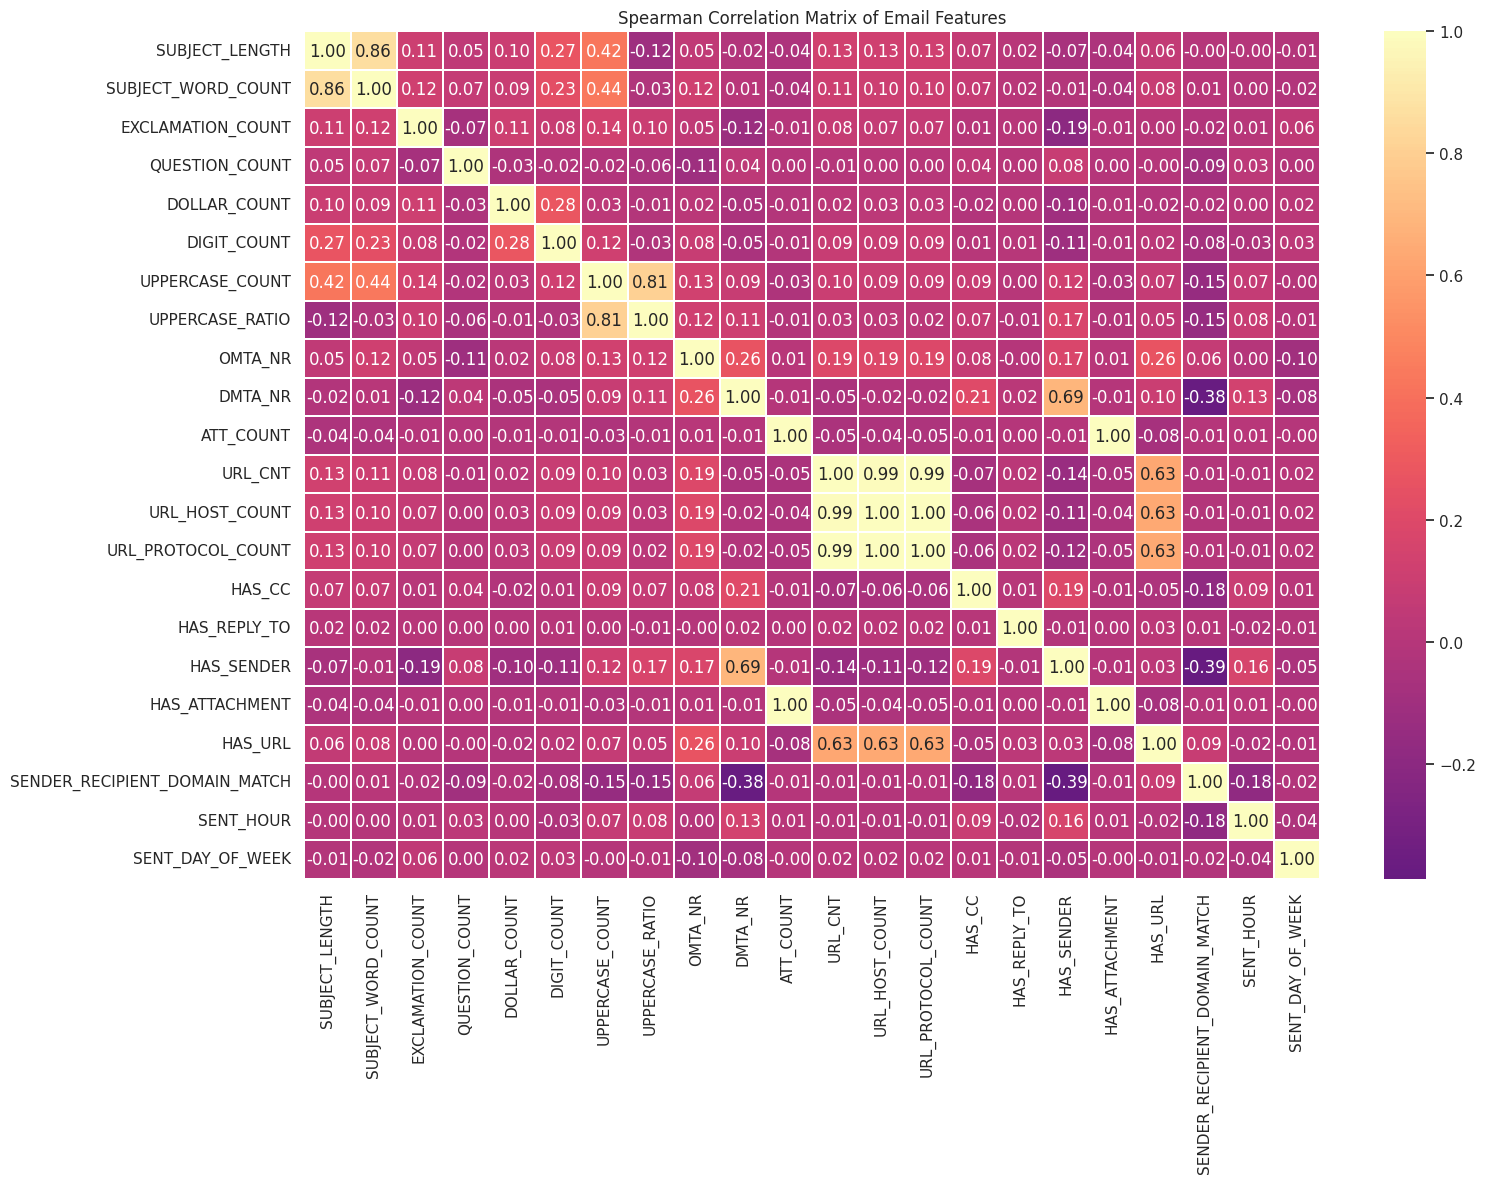

In [ ]:
# Create a correlation heatmap.
plt.figure(figsize=(16, 12))

sns.heatmap(
    spearman_matrix,
    cmap="magma",
    center=0,
    linewidths=0.2,
    annot= True,
    fmt=".2f"
)

plt.title("Spearman Correlation Matrix of Email Features")
plt.tight_layout()
plt.show()

In [ ]:
# Create an empty list to store statistical test results.
mann_whitney_results = []

# Perform a Mann-Whitney U test for every numerical feature.
for feature in numeric_features:

    # Extract the feature values for Ham emails.
    ham_values = model_df.loc[
        model_df["SPAM_BINARY"] == 0,
        feature
    ].dropna()

    # Extract the feature values for Spam emails.
    spam_values = model_df.loc[
        model_df["SPAM_BINARY"] == 1,
        feature
    ].dropna()

    # Perform the two-sided Mann-Whitney U test.
    statistic, p_value = mannwhitneyu(
        ham_values,
        spam_values,
        alternative="two-sided"
    )

    # Store the results.
    mann_whitney_results.append({
        "Feature": feature,
        "U_Statistic": statistic,
        "P_Value": p_value
    })

# Convert results into a DataFrame.
mann_whitney_results = pd.DataFrame(
    mann_whitney_results
)

# Apply Benjamini-Hochberg correction.
mann_whitney_results[
    "Adjusted_P_Value"
] = multipletests(
    mann_whitney_results["P_Value"],
    method="fdr_bh"
)[1]

# Identify statistically significant variables.
mann_whitney_results["Significant"] = (
    mann_whitney_results["Adjusted_P_Value"] < 0.05
)

# Sort by adjusted p-value.
mann_whitney_results = (
    mann_whitney_results
    .sort_values("Adjusted_P_Value")
    .reset_index(drop=True)
)

# Display the results.
display(mann_whitney_results)

,Feature,U_Statistic,P_Value,Adjusted_P_Value,Significant
0,HAS_SENDER,5419132.5,1.113959e-217,2.450709e-216,True
1,EXCLAMATION_COUNT,2918602.5,3.785646e-157,4.164211e-156,True
2,DMTA_NR,5274726.5,3.193545e-138,2.341933e-137,True
3,DOLLAR_COUNT,3534050.0,1.464244e-50,8.053344e-50,True
4,DIGIT_COUNT,3179276.5,4.579866e-38,2.015141e-37,True
5,URL_CNT,3209721.5,1.386304e-20,5.083113e-20,True
6,URL_PROTOCOL_COUNT,3257313.5,6.683396e-18,2.100496e-17,True
7,URL_HOST_COUNT,3275204.5,9.398577e-17,2.584609e-16,True
8,OMTA_NR,3641080.0,7.336041e-15,1.793254e-14,True
9,SENDER_RECIPIENT_DOMAIN_MATCH,4037639.5,6.241678e-13,1.373169e-12,True


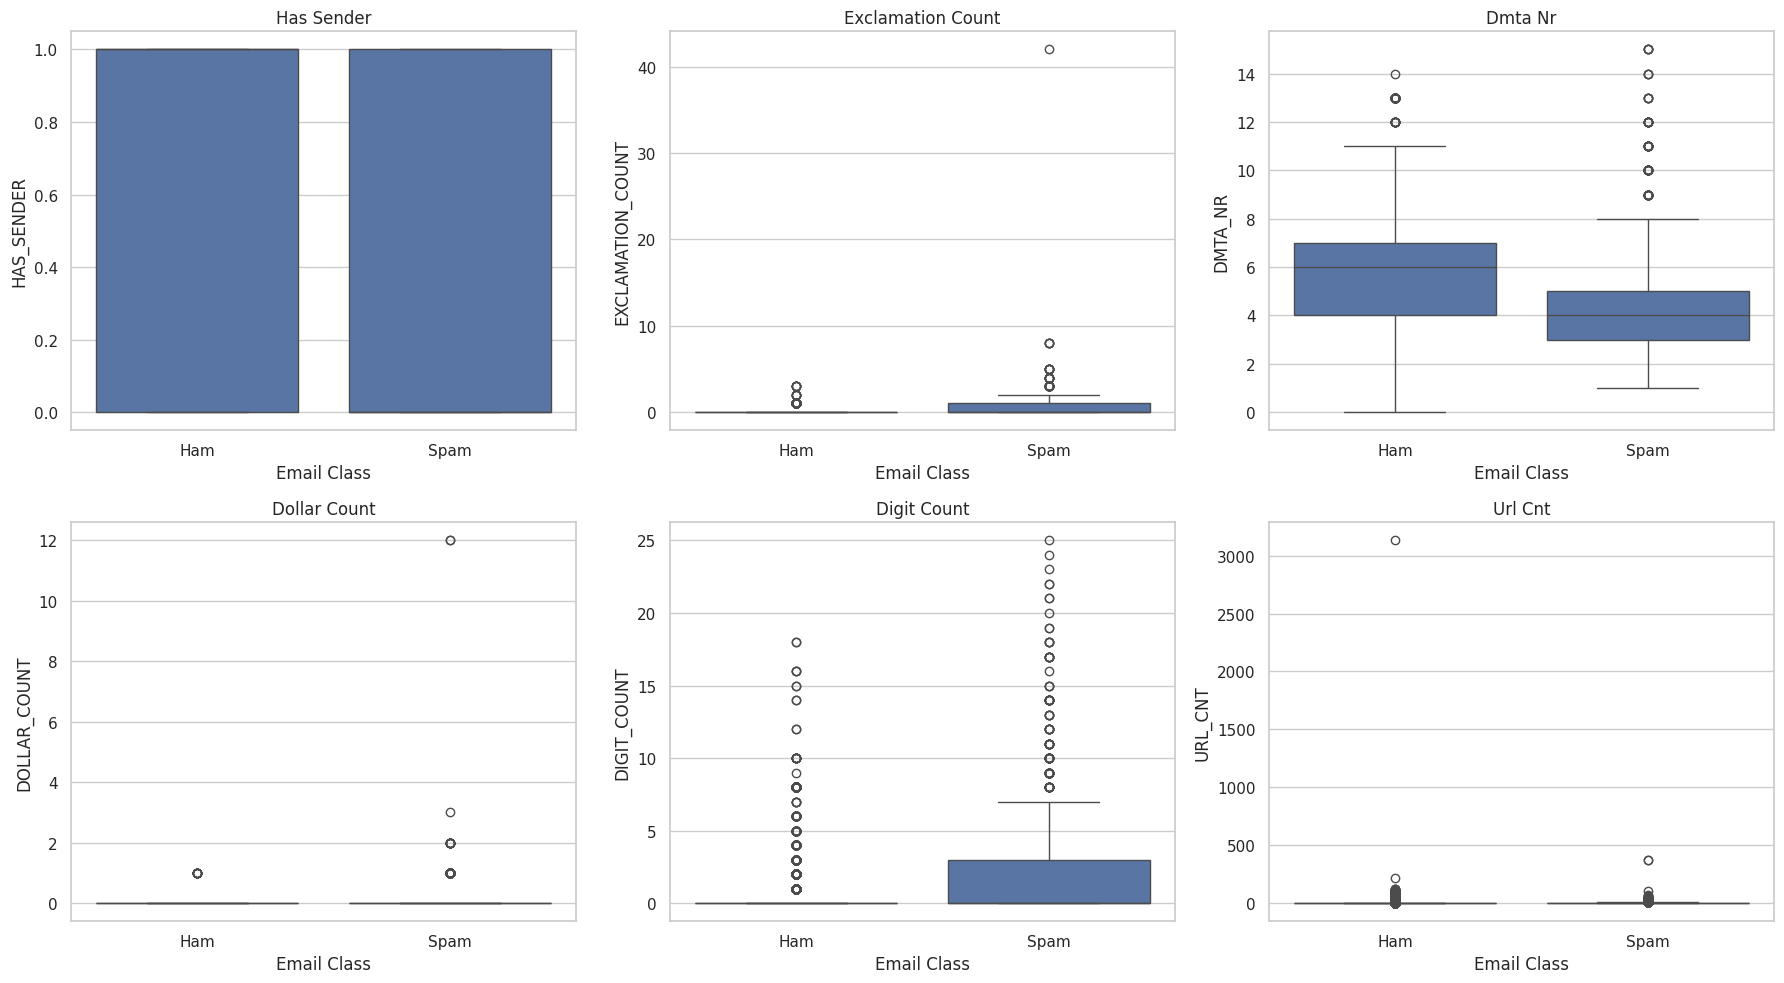

In [ ]:
# Select the six features with the strongest statistical evidence.
top_statistical_features = (
    mann_whitney_results
    .head(6)["Feature"]
    .tolist()
)

# Create a two-by-three subplot layout.
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

# Flatten the axes array.
axes = axes.flatten()

# Plot each statistically significant feature.
for index, feature in enumerate(
    top_statistical_features
):

    sns.boxplot(
        data=model_df,
        x="SPAM_LABEL",
        y=feature,
        order=["Ham", "Spam"],
        ax=axes[index]
    )

    axes[index].set_title(
        feature.replace("_", " ").title()
    )

    axes[index].set_xlabel("Email Class")
    axes[index].set_ylabel(feature)

# Improve subplot spacing.
plt.tight_layout()
plt.show()

In [ ]:
# Define numerical features with meaningful email-related information.
numeric_features = [
    "SUBJECT_LENGTH",
    "SUBJECT_WORD_COUNT",
    "EXCLAMATION_COUNT",
    "QUESTION_COUNT",
    "DOLLAR_COUNT",
    "DIGIT_COUNT",
    "UPPERCASE_COUNT",
    "UPPERCASE_RATIO",
    "OMTA_NR",
    "DMTA_NR",
    "OMTA_DELAY",
    "OMTA_TT",
    "DMTA_DELAY",
    "DMTA_TT",
    "ATT_COUNT",
    "URL_CNT",
    "URL_HOST_COUNT",
    "URL_PROTOCOL_COUNT",
    "HAS_CC",
    "HAS_REPLY_TO",
    "HAS_SENDER",
    "HAS_ATTACHMENT",
    "HAS_URL",
    "SENDER_RECIPIENT_DOMAIN_MATCH",
    "SENT_HOUR",
    "SENT_DAY_OF_WEEK"
]

# Define categorical variables with relatively manageable cardinality.
categorical_features = [
    "CONT_TYPE",
    "CONT_SUBTYPE",
    "ENC",
    "URL1_PROT",
    "URL2_PROT",
    "URL3_PROT",
    "ATT_FIRSTEXT"
]

# Define the cleaned email subject as the text feature.
text_feature = "SUBJECT_CLEAN"

# Create the predictor DataFrame.
X = model_df[
    [text_feature]
    + numeric_features
    + categorical_features
].copy()

# Define the binary target variable.
y = model_df["SPAM_BINARY"].copy()

# Convert infinite numerical values into missing values.
X[numeric_features] = (
    X[numeric_features]
    .replace([np.inf, -np.inf], np.nan)
)

# Ensure numerical columns are actually numeric.
for column in numeric_features:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

# Ensure categorical columns are treated as strings.
for column in categorical_features:
    X[column] = X[column].astype("object")

# Ensure the subject text is always represented as a string.
X[text_feature] = (
    X[text_feature]
    .fillna("")
    .astype(str)
)

# Display the final predictor dimensions.
print(f"Predictor matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Check remaining missing values.
remaining_missing = X.isnull().sum()

# Display only columns that still contain missing values.
display(
    remaining_missing[
        remaining_missing > 0
    ].sort_values(
        ascending=False
    )
)

Predictor matrix shape: (5961, 34)
Target vector shape: (5961,)


,0
ATT_FIRSTEXT,5938
URL3_PROT,4327
ENC,3252
URL2_PROT,2902
URL1_PROT,861
URL_CNT,1


In [ ]:
# Split the dataset into training and testing subsets.
# Stratification preserves the Ham and Spam proportions in both subsets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Display the dimensions of the two subsets.
print(f"Training records: {X_train.shape[0]}")
print(f"Testing records: {X_test.shape[0]}")

# Display the training class distribution.
print("\nTraining class distribution:")

training_distribution = (
    y_train
    .value_counts()
    .sort_index()
    .rename({
        0: "Ham",
        1: "Spam"
    })
)

display(training_distribution)

# Display the testing class distribution.
print("\nTesting class distribution:")

testing_distribution = (
    y_test
    .value_counts()
    .sort_index()
    .rename({
        0: "Ham",
        1: "Spam"
    })
)

display(testing_distribution)

Training records: 4768
Testing records: 1193

Training class distribution:


,count
SPAM_BINARY,
Ham,3315
Spam,1453



Testing class distribution:


,count
SPAM_BINARY,
Ham,830
Spam,363


In [ ]:
from sklearn.impute import SimpleImputer

# Create a function that returns a fresh preprocessing transformer.
# A new transformer is created for every model so that fitted information
# is never shared between different modelling experiments.

def create_preprocessor():

    # Create the numerical preprocessing pipeline.
    numerical_pipeline = SklearnPipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    # Create the categorical preprocessing pipeline.
    categorical_pipeline = SklearnPipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2
            )
        )
    ])

    # Create a fresh TF-IDF transformer for the email subject.
    text_pipeline = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=3000
    )

    # Combine text, numerical and categorical transformations.
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "text",
                text_pipeline,
                text_feature
            ),
            (
                "numeric",
                numerical_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ],
        remainder="drop"
    )

    return preprocessor


print(
    "Leakage-safe preprocessing function created."
)

Leakage-safe preprocessing function created.


In [ ]:
# Create the Logistic Regression pipeline.
# Preprocessing and SVD are fitted separately inside every CV fold.
logistic_pipeline = Pipeline([
    (
        "preprocessing",
        create_preprocessor()
    ),
    (
        "svd",
        TruncatedSVD(
            n_components=50,
            random_state=RANDOM_STATE
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

# Create the Linear Discriminant Analysis pipeline.
lda_pipeline = Pipeline([
    (
        "preprocessing",
        create_preprocessor()
    ),
    (
        "svd",
        TruncatedSVD(
            n_components=50,
            random_state=RANDOM_STATE
        )
    ),
    (
        "model",
        LinearDiscriminantAnalysis()
    )
])

# Create the K-Nearest Neighbour pipeline.
knn_pipeline = Pipeline([
    (
        "preprocessing",
        create_preprocessor()
    ),
    (
        "svd",
        TruncatedSVD(
            n_components=50,
            random_state=RANDOM_STATE
        )
    ),
    (
        "model",
        KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            metric="minkowski",
            p=2
        )
    )
])

# Create the Gaussian Naive Bayes pipeline.
naive_bayes_pipeline = Pipeline([
    (
        "preprocessing",
        create_preprocessor()
    ),
    (
        "svd",
        TruncatedSVD(
            n_components=50,
            random_state=RANDOM_STATE
        )
    ),
    (
        "model",
        GaussianNB()
    )
])

# Create the Support Vector Machine pipeline.
svm_pipeline = Pipeline([
    (
        "preprocessing",
        create_preprocessor()
    ),
    (
        "svd",
        TruncatedSVD(
            n_components=50,
            random_state=RANDOM_STATE
        )
    ),
    (
        "model",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        )
    )
])

# Store the five final baseline pipelines.
models = {
    "Logistic Regression": logistic_pipeline,
    "LDA": lda_pipeline,
    "KNN": knn_pipeline,
    "Naive Bayes": naive_bayes_pipeline,
    "SVM": svm_pipeline
}

print("Five leakage-safe classification pipelines created.")

for model_name in models:
    print(f"- {model_name}")

Five leakage-safe classification pipelines created.
- Logistic Regression
- LDA
- KNN
- Naive Bayes
- SVM


In [ ]:
# Create five stratified folds.
# Each fold maintains approximately the same Ham and Spam proportions.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Define the evaluation metrics.
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print(
    "Leakage-safe five-fold stratified cross-validation configured."
)

Leakage-safe five-fold stratified cross-validation configured.


In [ ]:
# Create a list for storing cross-validation results.
cv_results_list = []

# Evaluate every classification pipeline.
for model_name, model in models.items():

    print(
        f"Evaluating {model_name}..."
    )

    # Perform five-fold cross-validation.
    # The preprocessing, TF-IDF transformation and SVD are fitted
    # independently within each training fold.
    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    # Store the mean and standard deviation of each metric.
    cv_results_list.append({
        "Model": model_name,
        "Accuracy Mean": scores[
            "test_accuracy"
        ].mean(),
        "Accuracy SD": scores[
            "test_accuracy"
        ].std(),
        "Balanced Accuracy Mean": scores[
            "test_balanced_accuracy"
        ].mean(),
        "Precision Mean": scores[
            "test_precision"
        ].mean(),
        "Recall Mean": scores[
            "test_recall"
        ].mean(),
        "F1 Mean": scores[
            "test_f1"
        ].mean(),
        "ROC AUC Mean": scores[
            "test_roc_auc"
        ].mean()
    })

# Convert the results into a DataFrame.
cv_results = pd.DataFrame(
    cv_results_list
)

# Rank the models according to mean F1 score.
cv_results = (
    cv_results
    .sort_values(
        "F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the final leakage-safe CV results.
display(
    cv_results.round(4)
)

Evaluating Logistic Regression...
Evaluating LDA...
Evaluating KNN...
Evaluating Naive Bayes...
Evaluating SVM...


,Model,Accuracy Mean,Accuracy SD,Balanced Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC AUC Mean
0,SVM,0.9360,0.0071,0.9227,0.9003,0.8885,0.8943,0.9649
1,Logistic Regression,0.9163,0.0043,0.9027,0.8591,0.8679,0.8634,0.9526
2,KNN,0.9153,0.0155,0.8819,0.9142,0.7963,0.8509,0.9440
3,LDA,0.8876,0.0141,0.8444,0.8772,0.7337,0.7990,0.9419
4,Naive Bayes,0.7588,0.1076,0.7931,0.5971,0.8810,0.7028,0.8982


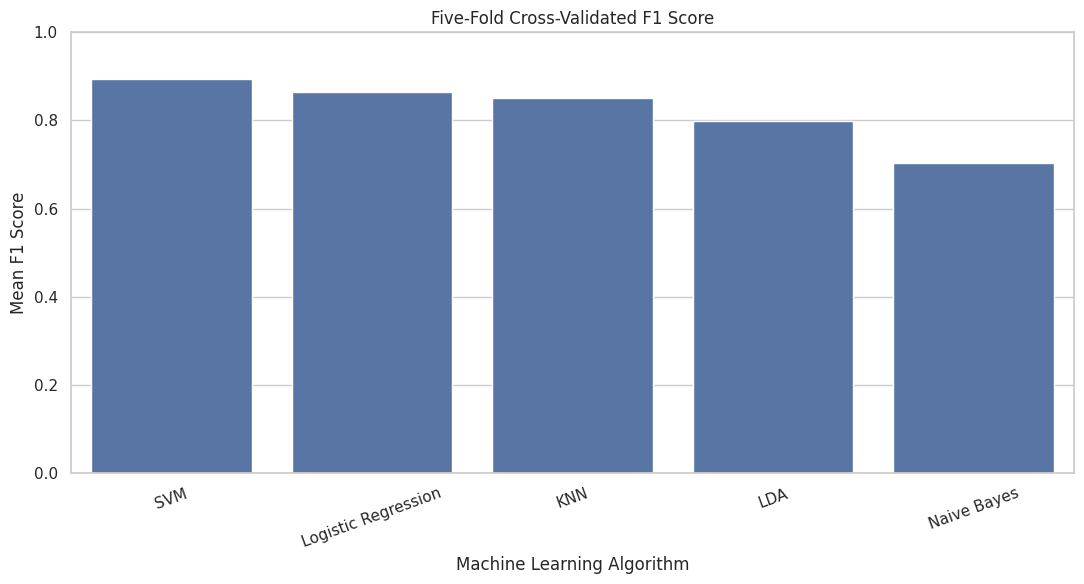

In [ ]:
# Create a visual comparison of cross-validated model performance.
plt.figure(
    figsize=(11, 6)
)

sns.barplot(
    data=cv_results,
    x="Model",
    y="F1 Mean"
)

# Add the chart title and axis labels.
plt.title(
    "Five-Fold Cross-Validated F1 Score"
)

plt.xlabel(
    "Machine Learning Algorithm"
)

plt.ylabel(
    "Mean F1 Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

In [ ]:
# Create a dictionary for the fitted final models.
fitted_models = {}

# Fit every leakage-safe pipeline using the complete training dataset.
for model_name, model in models.items():

    print(
        f"Training {model_name}..."
    )

    # Fit the complete pipeline.
    model.fit(
        X_train,
        y_train
    )

    # Store the fitted model.
    fitted_models[
        model_name
    ] = model

print(
    "\nAll five final models trained successfully."
)

Training Logistic Regression...
Training LDA...
Training KNN...
Training Naive Bayes...
Training SVM...

All five final models trained successfully.


In [ ]:
# Create a list for storing final test results.
final_evaluation_results = []

# Evaluate every fitted model on the untouched test set.
for model_name, model in fitted_models.items():

    print(
        f"Evaluating {model_name} on the test set..."
    )

    # Generate class predictions.
    y_pred = model.predict(
        X_test
    )

    # Generate probability or decision scores.
    if hasattr(
        model,
        "predict_proba"
    ):

        y_score = model.predict_proba(
            X_test
        )[:, 1]

    else:

        y_score = model.decision_function(
            X_test
        )

    # Calculate the evaluation metrics.
    final_evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC AUC": roc_auc_score(
            y_test,
            y_score
        )
    })

# Convert the results into a DataFrame.
final_evaluation = pd.DataFrame(
    final_evaluation_results
)

# Rank the models by F1 Score.
final_evaluation = (
    final_evaluation
    .sort_values(
        "F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the final test results.
display(
    final_evaluation.round(4)
)

Evaluating Logistic Regression on the test set...
Evaluating LDA on the test set...
Evaluating KNN on the test set...
Evaluating Naive Bayes on the test set...
Evaluating SVM on the test set...


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SVM,0.9288,0.9162,0.8819,0.8843,0.8831,0.9608
1,KNN,0.9220,0.8944,0.9116,0.8237,0.8654,0.9568
2,Logistic Regression,0.9078,0.8973,0.8338,0.8705,0.8518,0.9465
3,LDA,0.8818,0.8484,0.8343,0.7631,0.7971,0.9287
4,Naive Bayes,0.7527,0.7835,0.5609,0.8623,0.6797,0.8768


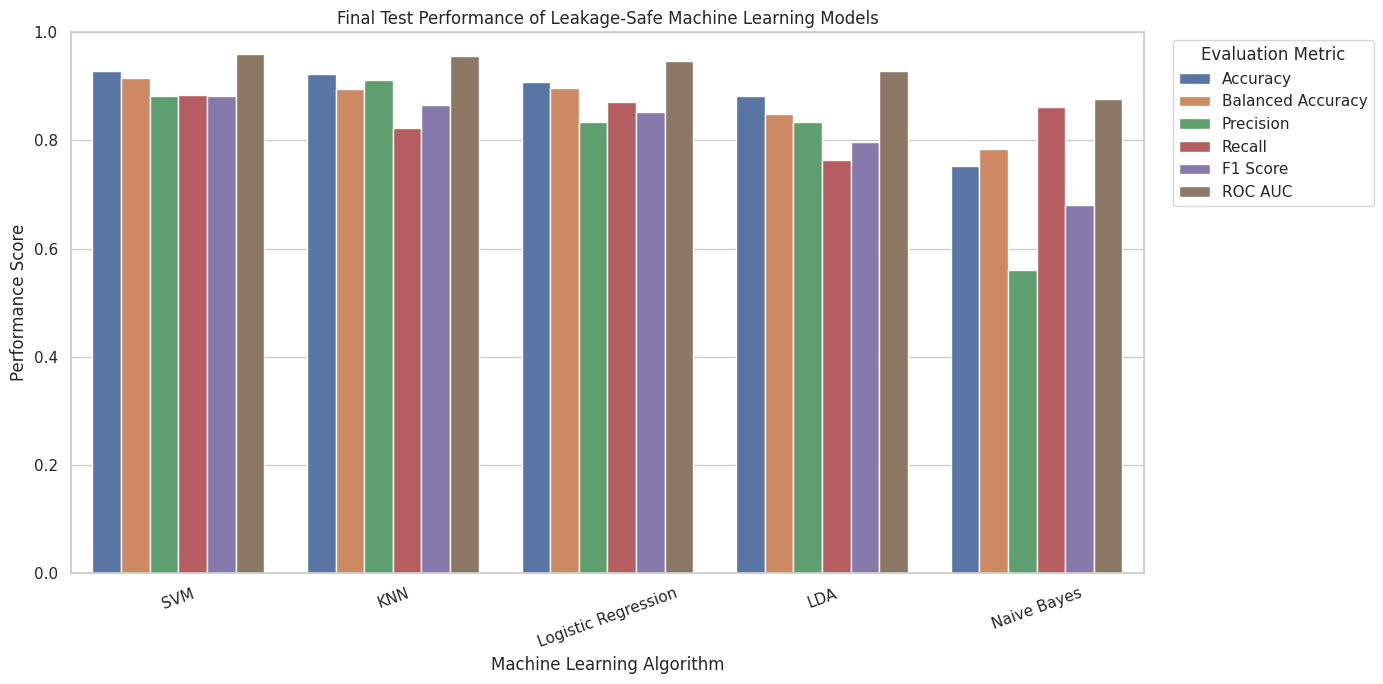

In [ ]:
# Reshape the final leakage-safe evaluation results.
comparison_data = final_evaluation.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

# Create the final model comparison chart.
plt.figure(
    figsize=(14, 7)
)

sns.barplot(
    data=comparison_data,
    x="Model",
    y="Score",
    hue="Metric"
)

# Add chart labels.
plt.title(
    "Final Test Performance of Leakage-Safe Machine Learning Models"
)

plt.xlabel(
    "Machine Learning Algorithm"
)

plt.ylabel(
    "Performance Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# Generate a detailed classification report for every final model.
for model_name, model in fitted_models.items():

    # Generate predictions on the independent test set.
    y_pred = model.predict(
        X_test
    )

    # Print the model name.
    print(
        f"\nClassification Report: {model_name}"
    )

    # Generate the precision, recall and F1 report.
    report = classification_report(
        y_test,
        y_pred,
        target_names=[
            "Ham",
            "Spam"
        ],
        digits=4,
        zero_division=0
    )

    # Display the report.
    print(report)


Classification Report: Logistic Regression
              precision    recall  f1-score   support

         Ham     0.9423    0.9241    0.9331       830
        Spam     0.8338    0.8705    0.8518       363

    accuracy                         0.9078      1193
   macro avg     0.8880    0.8973    0.8924      1193
weighted avg     0.9093    0.9078    0.9083      1193


Classification Report: LDA
              precision    recall  f1-score   support

         Ham     0.9001    0.9337    0.9166       830
        Spam     0.8343    0.7631    0.7971       363

    accuracy                         0.8818      1193
   macro avg     0.8672    0.8484    0.8569      1193
weighted avg     0.8801    0.8818    0.8803      1193


Classification Report: KNN
              precision    recall  f1-score   support

         Ham     0.9260    0.9651    0.9451       830
        Spam     0.9116    0.8237    0.8654       363

    accuracy                         0.9220      1193
   macro avg     0.9188    0

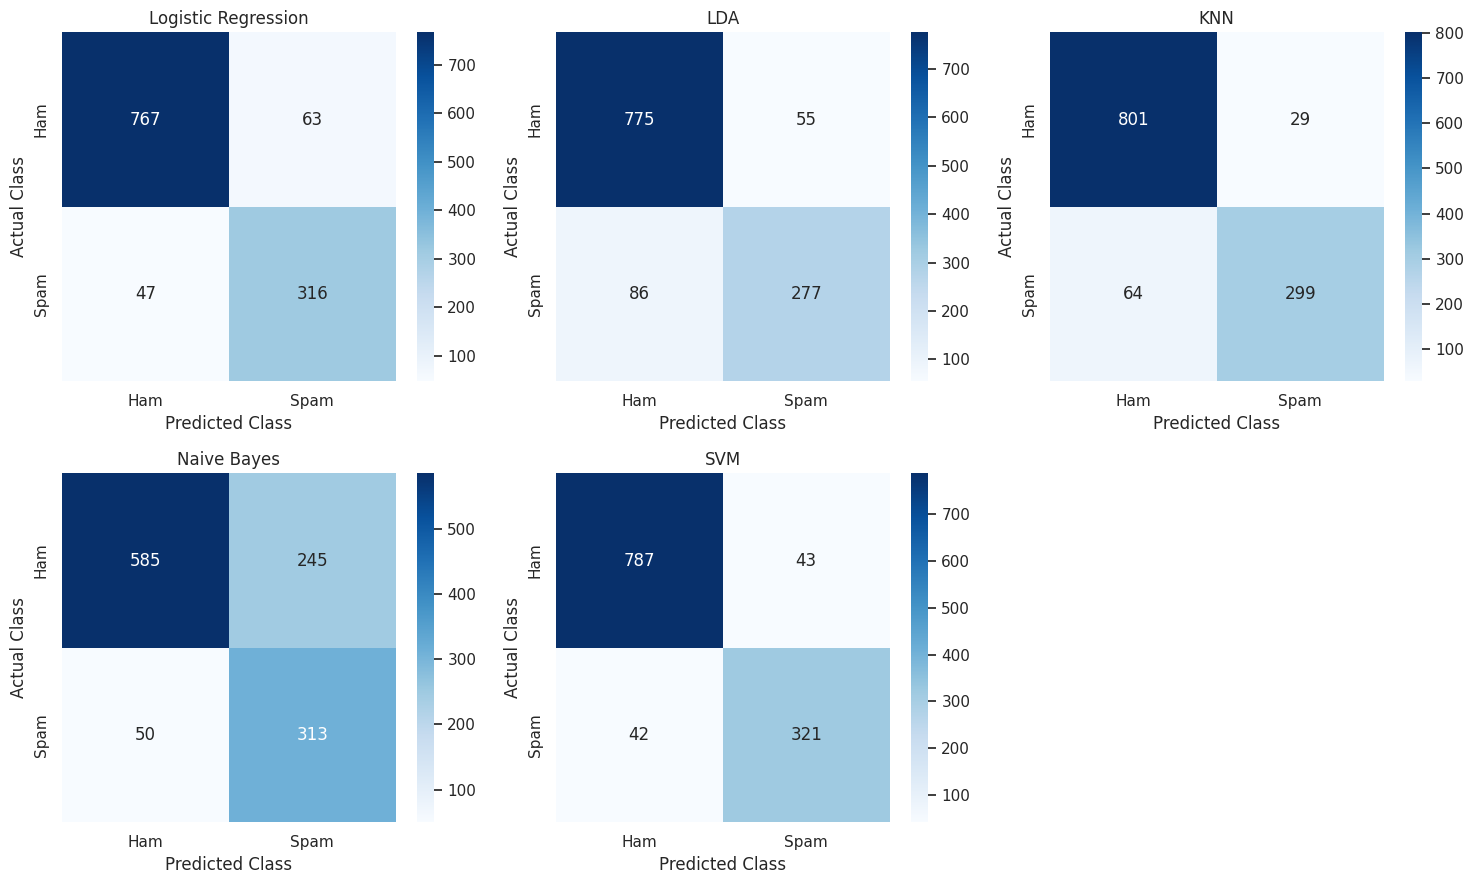

In [ ]:
# Create a figure containing one confusion matrix for each model.
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

# Flatten the axes array to simplify indexing.
axes = axes.flatten()

# Generate a confusion matrix for each model.
for index, (model_name, model) in enumerate(
    fitted_models.items()
):

    # Generate predictions.
    y_pred = model.predict(
        X_test
    )

    # Calculate the confusion matrix.
    cm = confusion_matrix(
        y_test,
        y_pred
    )

    # Plot the confusion matrix.
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Ham",
            "Spam"
        ],
        yticklabels=[
            "Ham",
            "Spam"
        ],
        ax=axes[index]
    )

    # Add model-specific labels.
    axes[index].set_title(
        model_name
    )

    axes[index].set_xlabel(
        "Predicted Class"
    )

    axes[index].set_ylabel(
        "Actual Class"
    )

# Hide the unused sixth subplot.
axes[-1].set_visible(False)

# Improve the overall layout.
plt.tight_layout()
plt.show()

In [ ]:
# Select the classifier with the highest test-set F1 score.
best_model_name = final_evaluation.iloc[0]["Model"]

# Retrieve the fitted best model.
best_model = fitted_models[
    best_model_name
]

# Display the selected model.
print(
    f"Best model based on test F1 score: "
    f"{best_model_name}"
)

# Display its main performance metrics.
best_row = final_evaluation.iloc[0]

print(
    f"Accuracy: "
    f"{best_row['Accuracy']:.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{best_row['Balanced Accuracy']:.4f}"
)

print(
    f"Precision: "
    f"{best_row['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_row['Recall']:.4f}"
)

print(
    f"F1 Score: "
    f"{best_row['F1 Score']:.4f}"
)

print(
    f"ROC AUC: "
    f"{best_row['ROC AUC']:.4f}"
)

Best model based on test F1 score: SVM
Accuracy: 0.9288
Balanced Accuracy: 0.9162
Precision: 0.8819
Recall: 0.8843
F1 Score: 0.8831
ROC AUC: 0.9608


In [ ]:
# Generate predictions from the selected best model.
best_predictions = best_model.predict(
    X_test
)

# Display precision, recall and F1 for both classes.
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Ham",
            "Spam"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Ham     0.9493    0.9482    0.9488       830
        Spam     0.8819    0.8843    0.8831       363

    accuracy                         0.9288      1193
   macro avg     0.9156    0.9162    0.9159      1193
weighted avg     0.9288    0.9288    0.9288      1193



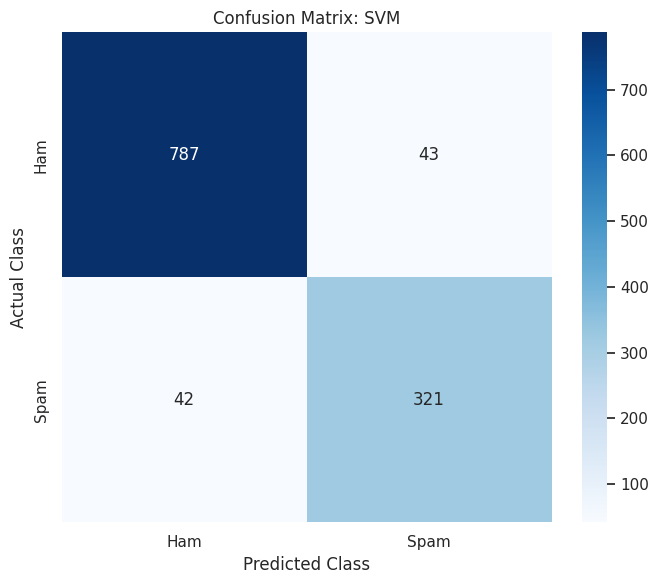

In [ ]:
# Calculate the confusion matrix.
cm = confusion_matrix(
    y_test,
    best_predictions
)

# Create the confusion matrix plot.
plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Ham",
        "Spam"
    ],
    yticklabels=[
        "Ham",
        "Spam"
    ]
)

# Add chart labels.
plt.title(
    f"Confusion Matrix: {best_model_name}"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.tight_layout()
plt.show()

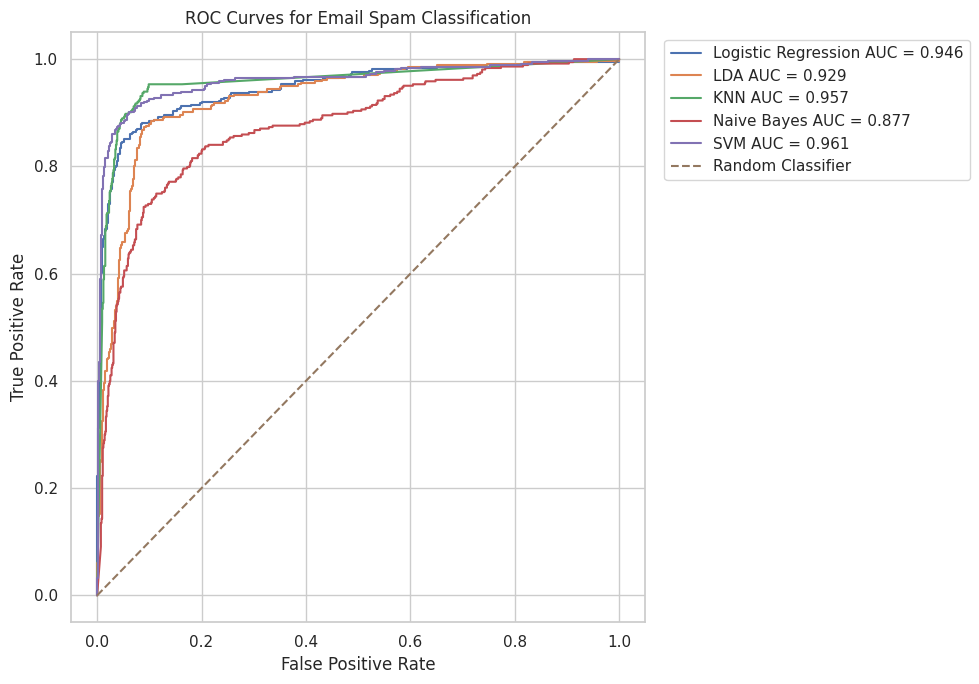

In [ ]:
# Create the ROC curve figure.
plt.figure(
    figsize=(10, 7)
)

# Calculate and plot the ROC curve for every model.
for model_name, model in fitted_models.items():

    # Obtain probability or decision scores.
    if hasattr(
        model,
        "predict_proba"
    ):

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

    else:

        probabilities = model.decision_function(
            X_test
        )

    # Calculate false-positive and true-positive rates.
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    # Calculate ROC-AUC.
    model_auc = auc(
        false_positive_rate,
        true_positive_rate
    )

    # Plot the ROC curve.
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} AUC = {model_auc:.3f}"
    )

# Add the random-classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

# Add labels.
plt.title(
    "ROC Curves for Email Spam Classification"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# Import the Mann-Whitney U statistical test.
from scipy.stats import mannwhitneyu

# Create a list to store statistical test results.
statistical_results = []

# Store the number of tests for multiple-comparison correction.
number_of_tests = len(numeric_features)

# Test each numerical feature against the binary Spam target.
for feature in numeric_features:

    # Convert the feature to numeric values.
    # Invalid values are converted to NaN.
    feature_values = pd.to_numeric(
        model_df[feature],
        errors="coerce"
    )

    # Replace infinite values with NaN.
    feature_values = feature_values.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Extract valid values for Ham emails.
    ham_values = feature_values[
        model_df["SPAM_BINARY"] == 0
    ].dropna()

    # Extract valid values for Spam emails.
    spam_values = feature_values[
        model_df["SPAM_BINARY"] == 1
    ].dropna()

    # Continue only when both groups contain sufficient observations.
    if (
        len(ham_values) >= 2
        and len(spam_values) >= 2
    ):

        # Check whether the feature contains variation.
        if (
            ham_values.nunique() > 1
            or spam_values.nunique() > 1
        ):

            # Perform the two-sided Mann-Whitney U test.
            statistic, p_value = mannwhitneyu(
                ham_values,
                spam_values,
                alternative="two-sided"
            )

            # Calculate the rank-biserial effect size.
            # This indicates the direction and magnitude of the
            # distributional difference between Ham and Spam.
            rank_biserial = (
                2 * statistic
                / (
                    len(ham_values)
                    * len(spam_values)
                )
            ) - 1

            # Store the statistical results.
            statistical_results.append({
                "Feature": feature,
                "Ham Median": ham_values.median(),
                "Spam Median": spam_values.median(),
                "U Statistic": statistic,
                "P Value": p_value,
                "Rank Biserial Correlation": rank_biserial,
                "Ham N": len(ham_values),
                "Spam N": len(spam_values)
            })

# Convert the statistical results into a DataFrame.
statistical_results_df = pd.DataFrame(
    statistical_results
)

# Check that at least one statistical test was successfully performed.
if statistical_results_df.empty:

    raise ValueError(
        "No numerical features could be tested. "
        "Check the feature names and target variable."
    )

# Apply Bonferroni correction for multiple comparisons.
statistical_results_df[
    "Adjusted P Value"
] = (
    statistical_results_df[
        "P Value"
    ]
    * number_of_tests
).clip(
    upper=1.0
)

# Identify statistically significant features.
statistical_results_df[
    "Significant"
] = (
    statistical_results_df[
        "Adjusted P Value"
    ] < 0.05
)

# Create an absolute effect-size column for ranking.
statistical_results_df[
    "Absolute Effect Size"
] = (
    statistical_results_df[
        "Rank Biserial Correlation"
    ].abs()
)

# Sort primarily by statistical significance and then by effect size.
statistical_results_df = (
    statistical_results_df
    .sort_values(
        [
            "Adjusted P Value",
            "Absolute Effect Size"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

# Display the complete statistical analysis.
display(
    statistical_results_df.round(5)
)

,Feature,Ham Median,Spam Median,U Statistic,P Value,Rank Biserial Correlation,Ham N,Spam N,Adjusted P Value,Significant,Absolute Effect Size
0,DMTA_DELAY,0.000000e+00,0.000000e+00,2426092.0,0.00000,-0.35539,4145,1816,0.00000,True,0.35539
1,HAS_SENDER,1.000000e+00,0.000000e+00,5419132.5,0.00000,0.43986,4145,1816,0.00000,True,0.43986
2,EXCLAMATION_COUNT,0.000000e+00,0.000000e+00,2918602.5,0.00000,-0.22453,4145,1816,0.00000,True,0.22453
3,DMTA_NR,6.000000e+00,4.000000e+00,5274726.5,0.00000,0.40149,4145,1816,0.00000,True,0.40149
4,DOLLAR_COUNT,0.000000e+00,0.000000e+00,3534050.0,0.00000,-0.06101,4145,1816,0.00000,True,0.06101
5,DIGIT_COUNT,0.000000e+00,0.000000e+00,3179276.5,0.00000,-0.15527,4145,1816,0.00000,True,0.15527
6,URL_CNT,1.000000e+00,2.000000e+00,3209721.5,0.00000,-0.14671,4145,1815,0.00000,True,0.14671
7,URL_PROTOCOL_COUNT,1.000000e+00,2.000000e+00,3257313.5,0.00000,-0.13454,4145,1816,0.00000,True,0.13454
8,URL_HOST_COUNT,1.000000e+00,2.000000e+00,3275204.5,0.00000,-0.12978,4145,1816,0.00000,True,0.12978
9,OMTA_NR,1.000000e+00,1.000000e+00,3641080.0,0.00000,-0.03257,4145,1816,0.00000,True,0.03257


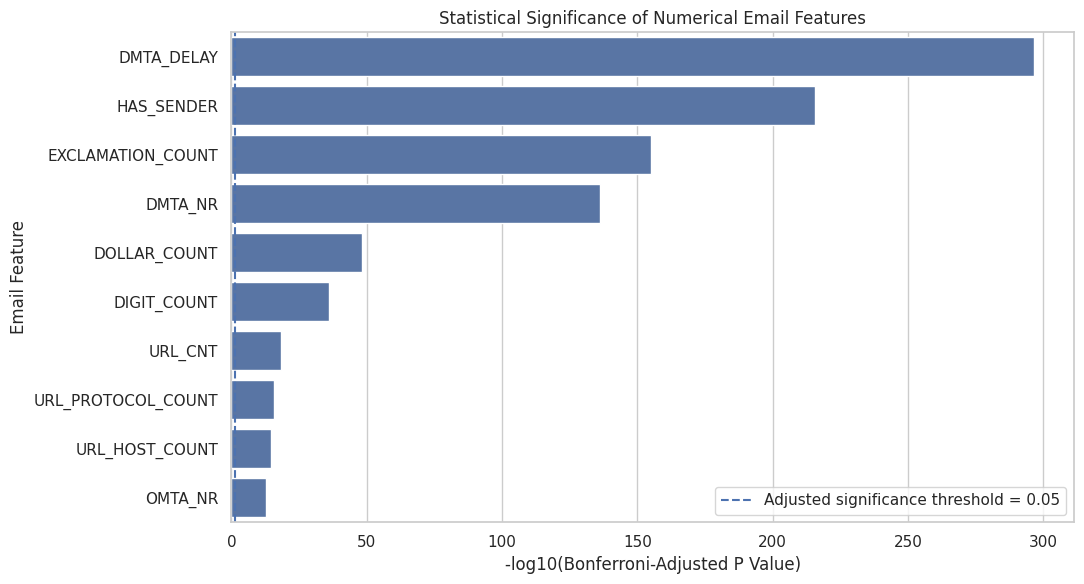

In [ ]:
# Select the ten features with the smallest adjusted p-values.
top_statistical_features = (
    statistical_results_df
    .sort_values(
        "Adjusted P Value",
        ascending=True
    )
    .head(10)
    .copy()
)

# Replace zero p-values with the smallest positive floating-point value.
# This prevents problems when calculating the logarithm.
top_statistical_features[
    "Adjusted P Value"
] = top_statistical_features[
    "Adjusted P Value"
].clip(
    lower=np.finfo(float).tiny
)

# Calculate the negative log10 of the adjusted p-value.
top_statistical_features[
    "Negative Log10 Adjusted P Value"
] = -np.log10(
    top_statistical_features[
        "Adjusted P Value"
    ]
)

# Calculate the equivalent significance threshold.
significance_threshold = -np.log10(
    0.05
)

# Create the statistical significance plot.
plt.figure(
    figsize=(11, 6)
)

sns.barplot(
    data=top_statistical_features,
    x="Negative Log10 Adjusted P Value",
    y="Feature"
)

# Add the adjusted p-value significance threshold.
plt.axvline(
    significance_threshold,
    linestyle="--",
    label="Adjusted significance threshold = 0.05"
)

# Add chart title.
plt.title(
    "Statistical Significance of Numerical Email Features"
)

# Add axis labels.
plt.xlabel(
    "-log10(Bonferroni-Adjusted P Value)"
)

plt.ylabel(
    "Email Feature"
)

# Add the legend.
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Import the chi-square test.
from scipy.stats import chi2_contingency

# Create a list for categorical statistical results.
categorical_statistical_results = []

# Test each categorical feature against the Spam class.
for feature in categorical_features:

    # Create a contingency table.
    contingency_table = pd.crosstab(
        model_df[feature].fillna("Missing"),
        model_df["SPAM_BINARY"]
    )

    # Perform the chi-square test.
    chi2, p_value, degrees_of_freedom, expected = (
        chi2_contingency(
            contingency_table
        )
    )

    # Calculate the total number of observations.
    total_observations = (
        contingency_table.values.sum()
    )

    # Calculate Cramer's V as an effect-size measure.
    minimum_dimension = min(
        contingency_table.shape
    ) - 1

    if minimum_dimension > 0:

        cramers_v = np.sqrt(
            chi2
            / (
                total_observations
                * minimum_dimension
            )
        )

    else:

        cramers_v = np.nan

    # Store the statistical results.
    categorical_statistical_results.append({
        "Feature": feature,
        "Chi Square": chi2,
        "Degrees of Freedom": degrees_of_freedom,
        "P Value": p_value,
        "Cramers V": cramers_v
    })

# Convert results to a DataFrame.
categorical_statistical_results_df = pd.DataFrame(
    categorical_statistical_results
)

# Apply Bonferroni correction.
categorical_statistical_results_df[
    "Adjusted P Value"
] = (
    categorical_statistical_results_df["P Value"]
    * len(categorical_statistical_results_df)
).clip(
    upper=1.0
)

# Identify statistically significant variables.
categorical_statistical_results_df[
    "Significant"
] = (
    categorical_statistical_results_df[
        "Adjusted P Value"
    ] < 0.05
)

# Sort by adjusted p-value.
categorical_statistical_results_df = (
    categorical_statistical_results_df
    .sort_values(
        "Adjusted P Value"
    )
    .reset_index(drop=True)
)

# Display the results.
display(
    categorical_statistical_results_df.round(5)
)

,Feature,Chi Square,Degrees of Freedom,P Value,Cramers V,Adjusted P Value,Significant
0,CONT_SUBTYPE,2229.59227,14,0.00000,0.61158,0.00000,True
1,ENC,849.75589,9,0.00000,0.37756,0.00000,True
2,CONT_TYPE,361.34051,5,0.00000,0.24621,0.00000,True
3,URL1_PROT,163.49677,4,0.00000,0.16561,0.00000,True
4,URL3_PROT,158.88956,4,0.00000,0.16326,0.00000,True
5,URL2_PROT,134.29791,5,0.00000,0.15010,0.00000,True
6,ATT_FIRSTEXT,29.24926,13,0.00603,0.07005,0.04223,True


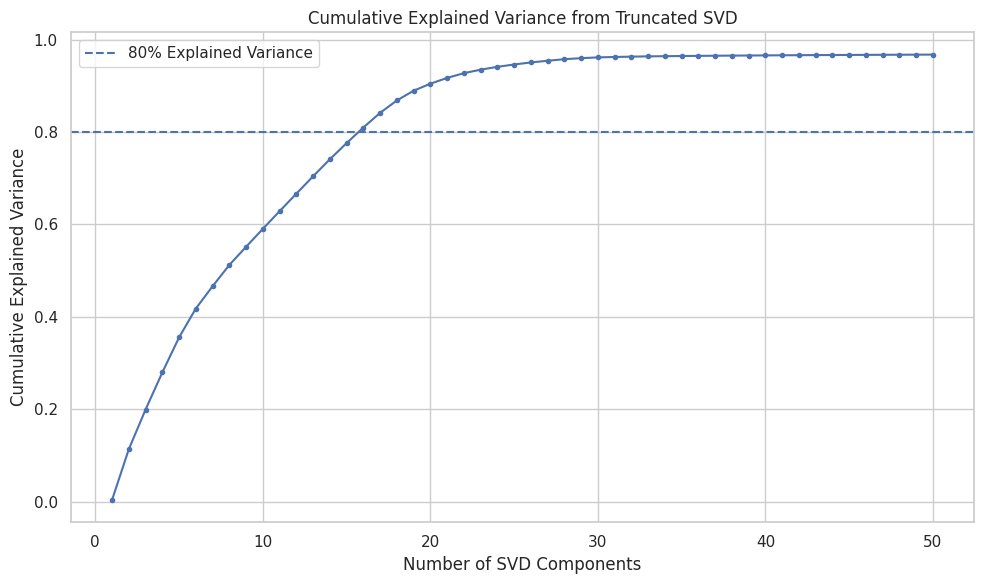

Total explained variance: 0.9676


In [ ]:
# Select the Logistic Regression pipeline as the reference model.
# The same SVD configuration is used across the five baseline models.
reference_model = models[
    "Logistic Regression"
]

# Extract the fitted SVD component from the trained pipeline.
fitted_svd = reference_model.named_steps[
    "svd"
]

# Calculate the cumulative explained variance.
cumulative_variance = np.cumsum(
    fitted_svd.explained_variance_ratio_
)

# Create the component index.
components = np.arange(
    1,
    len(cumulative_variance) + 1
)

# Plot cumulative explained variance.
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    components,
    cumulative_variance,
    marker="o",
    markersize=3
)

# Add the 80 percent reference line.
plt.axhline(
    0.80,
    linestyle="--",
    label="80% Explained Variance"
)

# Add chart labels.
plt.title(
    "Cumulative Explained Variance from Truncated SVD"
)

plt.xlabel(
    "Number of SVD Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.legend()

plt.tight_layout()
plt.show()

# Display the total variance explained by the selected components.
print(
    f"Total explained variance: "
    f"{cumulative_variance[-1]:.4f}"
)

In [ ]:
# Import GridSearchCV.
from sklearn.model_selection import GridSearchCV

# Define hyperparameters for the Logistic Regression model.
# The parameter names use the pipeline step name "model".
# The SVD parameter uses the pipeline step name "svd".
logistic_parameters = {
    "svd__n_components": [
        30,
        50,
        75
    ],
    "model__C": [
        0.1,
        1.0,
        10.0
    ]
}

# Use the complete leakage-safe Logistic Regression pipeline.
# This pipeline performs TF-IDF, imputation, encoding and SVD
# before Logistic Regression.
logistic_grid = GridSearchCV(
    estimator=models[
        "Logistic Regression"
    ],
    param_grid=logistic_parameters,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    error_score="raise"
)

# Run hyperparameter optimisation using the raw training data.
# The pipeline automatically converts the text and metadata into
# numerical features inside every cross-validation fold.
logistic_grid.fit(
    X_train,
    y_train
)

# Display the best hyperparameter combination.
print(
    "Best Logistic Regression parameters:"
)

print(
    logistic_grid.best_params_
)

# Display the best cross-validation F1 score.
print(
    f"Best CV F1 Score: "
    f"{logistic_grid.best_score_:.4f}"
)

Best Logistic Regression parameters:
{'model__C': 10.0, 'svd__n_components': 75}
Best CV F1 Score: 0.8720


In [ ]:
# Define the KNN hyperparameter grid.
# The "model__" prefix refers to parameters inside the KNN step.
# The "svd__" prefix refers to parameters inside the SVD step.
knn_parameters = {
    "svd__n_components": [
        30,
        50,
        75
    ],
    "model__n_neighbors": [
        3,
        5,
        7,
        9,
        11
    ],
    "model__weights": [
        "uniform",
        "distance"
    ],
    "model__p": [
        1,
        2
    ]
}

# Use the complete leakage-safe KNN pipeline.
# This pipeline performs text processing, metadata preprocessing,
# dimensionality reduction and KNN classification.
knn_grid = GridSearchCV(
    estimator=models[
        "KNN"
    ],
    param_grid=knn_parameters,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    error_score="raise"
)

# Perform hyperparameter optimisation using the raw training data.
# The pipeline handles the text and categorical variables internally.
knn_grid.fit(
    X_train,
    y_train
)

# Display the optimal hyperparameter configuration.
print(
    "Best KNN parameters:"
)

print(
    knn_grid.best_params_
)

# Display the best cross-validation F1 score.
print(
    f"Best CV F1 Score: "
    f"{knn_grid.best_score_:.4f}"
)

Best KNN parameters:
{'model__n_neighbors': 5, 'model__p': 1, 'model__weights': 'distance', 'svd__n_components': 50}
Best CV F1 Score: 0.8734


In [ ]:
# Define the SVM hyperparameter grid.
# The "svd__" prefix refers to the SVD step in the pipeline.
# The "model__" prefix refers to the SVM classifier.
svm_parameters = {
    "svd__n_components": [
        30,
        50,
        75
    ],
    "model__C": [
        0.1,
        1.0,
        10.0
    ],
    "model__gamma": [
        "scale",
        0.01,
        0.1
    ]
}

# Use the complete leakage-safe SVM pipeline.
# The pipeline handles text preprocessing, numerical imputation,
# categorical encoding, SVD and SVM classification.
svm_grid = GridSearchCV(
    estimator=models[
        "SVM"
    ],
    param_grid=svm_parameters,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    error_score="raise"
)

# Perform hyperparameter optimisation using the raw training data.
# All preprocessing steps are fitted independently within each
# cross-validation training fold.
svm_grid.fit(
    X_train,
    y_train
)

# Display the optimal hyperparameter configuration.
print(
    "Best SVM parameters:"
)

print(
    svm_grid.best_params_
)

# Display the best cross-validation F1 score.
print(
    f"Best CV F1 Score: "
    f"{svm_grid.best_score_:.4f}"
)

Best SVM parameters:
{'model__C': 10.0, 'model__gamma': 'scale', 'svd__n_components': 75}
Best CV F1 Score: 0.9089


In [ ]:
# Store the baseline F1 scores.
baseline_f1 = (
    final_evaluation.set_index("Model")["F1 Score"]
)

# Store the optimised F1 scores.
optimised_f1 = {
    "Logistic Regression": logistic_grid.best_score_,
    "KNN": knn_grid.best_score_,
    "SVM": svm_grid.best_score_
}

# Create a comparison table.
optimisation_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM"
    ],
    "Baseline F1": [
        baseline_f1.get(
            "Logistic Regression",
            np.nan
        ),
        baseline_f1.get(
            "KNN",
            np.nan
        ),
        baseline_f1.get(
            "SVM",
            np.nan
        )
    ],
    "Optimised CV F1": [
        optimised_f1[
            "Logistic Regression"
        ],
        optimised_f1[
            "KNN"
        ],
        optimised_f1[
            "SVM"
        ]
    ]
})

# Calculate the change in F1.
optimisation_comparison[
    "F1 Improvement"
] = (
    optimisation_comparison[
        "Optimised CV F1"
    ]
    - optimisation_comparison[
        "Baseline F1"
    ]
)

# Display the comparison.
display(
    optimisation_comparison.round(4)
)

,Model,Baseline F1,Optimised CV F1,F1 Improvement
0,Logistic Regression,0.8518,0.8720,0.0202
1,KNN,0.8654,0.8734,0.0080
2,SVM,0.8831,0.9089,0.0258


In [ ]:
# Store the optimised models.
optimised_models = {
    "Optimised Logistic Regression": logistic_grid.best_estimator_,
    "Optimised KNN": knn_grid.best_estimator_,
    "Optimised SVM": svm_grid.best_estimator_
}

# Create a list for the optimised test results.
optimised_test_results = []

# Evaluate every optimised model.
for model_name, model in optimised_models.items():

    # Generate predictions.
    predictions = model.predict(
        X_test
    )

    # Generate probability or decision scores.
    if hasattr(
        model,
        "predict_proba"
    ):

        scores = model.predict_proba(
            X_test
        )[:, 1]

    else:

        scores = model.decision_function(
            X_test
        )

    # Store the final test metrics.
    optimised_test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC AUC": roc_auc_score(
            y_test,
            scores
        )
    })

# Convert the results into a DataFrame.
optimised_test_results_df = pd.DataFrame(
    optimised_test_results
)

# Rank by F1 Score.
optimised_test_results_df = (
    optimised_test_results_df
    .sort_values(
        "F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the results.
display(
    optimised_test_results_df.round(4)
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Optimised SVM,0.9489,0.9423,0.9081,0.9256,0.9168,0.9754
1,Optimised Logistic Regression,0.9220,0.9153,0.8534,0.8981,0.8752,0.9612
2,Optimised KNN,0.9262,0.9013,0.9129,0.8375,0.8736,0.9572


In [ ]:
# Create a copy of the baseline results.
baseline_results = final_evaluation.copy()

# Add an optimisation status.
baseline_results[
    "Model Type"
] = "Baseline"

# Add the optimised model results.
optimised_results = (
    optimised_test_results_df
    .copy()
)

optimised_results[
    "Model Type"
] = "Optimised"

# Combine both result tables.
complete_model_results = pd.concat(
    [
        baseline_results,
        optimised_results
    ],
    ignore_index=True
)

# Rank all models by F1 Score.
complete_model_results = (
    complete_model_results
    .sort_values(
        "F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the complete comparison.
display(
    complete_model_results.round(4)
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC,Model Type
0,Optimised SVM,0.9489,0.9423,0.9081,0.9256,0.9168,0.9754,Optimised
1,SVM,0.9288,0.9162,0.8819,0.8843,0.8831,0.9608,Baseline
2,Optimised Logistic Regression,0.9220,0.9153,0.8534,0.8981,0.8752,0.9612,Optimised
3,Optimised KNN,0.9262,0.9013,0.9129,0.8375,0.8736,0.9572,Optimised
4,KNN,0.9220,0.8944,0.9116,0.8237,0.8654,0.9568,Baseline
5,Logistic Regression,0.9078,0.8973,0.8338,0.8705,0.8518,0.9465,Baseline
6,LDA,0.8818,0.8484,0.8343,0.7631,0.7971,0.9287,Baseline
7,Naive Bayes,0.7527,0.7835,0.5609,0.8623,0.6797,0.8768,Baseline


In [ ]:
# Identify the model with the highest final test F1 score.
final_best_model_name = (
    complete_model_results
    .iloc[0]["Model"]
)

# Retrieve the final model results.
final_best_results = (
    complete_model_results
    .iloc[0]
)

# Display the final selected model.
print(
    f"Final selected model: "
    f"{final_best_model_name}"
)

# Display all major performance measures.
print(
    f"Accuracy: "
    f"{final_best_results['Accuracy']:.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{final_best_results['Balanced Accuracy']:.4f}"
)

print(
    f"Precision: "
    f"{final_best_results['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{final_best_results['Recall']:.4f}"
)

print(
    f"F1 Score: "
    f"{final_best_results['F1 Score']:.4f}"
)

print(
    f"ROC AUC: "
    f"{final_best_results['ROC AUC']:.4f}"
)

Final selected model: Optimised SVM
Accuracy: 0.9489
Balanced Accuracy: 0.9423
Precision: 0.9081
Recall: 0.9256
F1 Score: 0.9168
ROC AUC: 0.9754


In [ ]:
# Select the final model object.
if final_best_model_name == "Optimised Logistic Regression":

    final_model = logistic_grid.best_estimator_

elif final_best_model_name == "Optimised KNN":

    final_model = knn_grid.best_estimator_

elif final_best_model_name == "Optimised SVM":

    final_model = svm_grid.best_estimator_

else:

    final_model = fitted_models[
        final_best_model_name
    ]

# Generate predictions from the final model.
final_predictions = final_model.predict(
    X_test
)

# Identify false positives.
# These are legitimate emails incorrectly classified as Spam.
false_positive_mask = (
    (y_test == 0)
    & (final_predictions == 1)
)

# Identify false negatives.
# These are Spam emails incorrectly classified as Ham.
false_negative_mask = (
    (y_test == 1)
    & (final_predictions == 0)
)

# Display the error counts.
print(
    f"False Positives: "
    f"{false_positive_mask.sum()}"
)

print(
    f"False Negatives: "
    f"{false_negative_mask.sum()}"
)

# Display the false-positive rate.
false_positive_rate = (
    false_positive_mask.sum()
    / (y_test == 0).sum()
)

print(
    f"False Positive Rate: "
    f"{false_positive_rate:.4f}"
)

# Display the false-negative rate.
false_negative_rate = (
    false_negative_mask.sum()
    / (y_test == 1).sum()
)

print(
    f"False Negative Rate: "
    f"{false_negative_rate:.4f}"
)

False Positives: 34
False Negatives: 27
False Positive Rate: 0.0410
False Negative Rate: 0.0744


In [ ]:
# Recover the original test-set indices.
test_indices = X_test.index

# Create an error-analysis DataFrame.
error_analysis = model_df.loc[
    test_indices,
    [
        "SUBJECT",
        "SPAM_LABEL"
    ]
].copy()

# Add actual and predicted labels.
error_analysis[
    "Actual"
] = y_test.values

error_analysis[
    "Predicted"
] = final_predictions

# Create a human-readable actual label.
error_analysis[
    "Actual Label"
] = error_analysis[
    "Actual"
].map({
    0: "Ham",
    1: "Spam"
})

# Create a human-readable predicted label.
error_analysis[
    "Predicted Label"
] = error_analysis[
    "Predicted"
].map({
    0: "Ham",
    1: "Spam"
})

# Select only incorrectly classified emails.
misclassified_emails = error_analysis[
    error_analysis["Actual"]
    != error_analysis["Predicted"]
].copy()

# Display a sample of misclassified emails.
display(
    misclassified_emails[
        [
            "SUBJECT",
            "Actual Label",
            "Predicted Label"
        ]
    ].head(20)
)

,SUBJECT,Actual Label,Predicted Label
5328,Still looking for a house?,Spam,Ham
4000,"fast ship Viagra, Phentermine, etc... ...",Spam,Ham
2845,Low Price Smokes,Spam,Ham
5153,Re: zzzz@spamassassin.taint.org,Spam,Ham
3094,"iSilo announcements (August 15, 2002)",Ham,Spam
1543,Cron <yyyy@dogma> /home/yyyy/logs/runme,Ham,Spam
1640,Cell phones coming soon,Ham,Spam
1567,Re: GA Development (was Re: [SAdev] [Bug 1030]...,Ham,Spam
1692,[SA] Job Update,Spam,Ham
552,[ILUG] Re: whats up -colonize,Spam,Ham


In [ ]:
# Create an output directory.
output_directory = "email_spam_final_results"

os.makedirs(
    output_directory,
    exist_ok=True
)

# Save the statistical numerical-feature analysis.
statistical_results_df.to_csv(
    os.path.join(
        output_directory,
        "numerical_statistical_tests.csv"
    ),
    index=False
)

# Save the categorical statistical analysis.
categorical_statistical_results_df.to_csv(
    os.path.join(
        output_directory,
        "categorical_statistical_tests.csv"
    ),
    index=False
)

# Save the baseline model results.
final_evaluation.to_csv(
    os.path.join(
        output_directory,
        "baseline_model_results.csv"
    ),
    index=False
)

# Save the optimised model results.
optimised_test_results_df.to_csv(
    os.path.join(
        output_directory,
        "optimised_model_results.csv"
    ),
    index=False
)

# Save the complete model comparison.
complete_model_results.to_csv(
    os.path.join(
        output_directory,
        "complete_model_comparison.csv"
    ),
    index=False
)

# Save the misclassified email analysis.
misclassified_emails.to_csv(
    os.path.join(
        output_directory,
        "misclassified_emails.csv"
    ),
    index=False
)

print(
    "All final analytical results have been saved successfully."
)

All final analytical results have been saved successfully.
